# Multivariate analyisis of the sensory data

## Import dependencies

In [2]:
import os
os.chdir('..')  #cd to coffeeleafinfuses folder

import pandas as pd
import numpy as np
import mca
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
from src.utils import load_config
from math import pi

## Data import

In [2]:
#load config file
config = load_config(path='config/config.yaml', section='sensory')
hot_infuses = Path(config['stable_hot'])
cold_infuses = Path(config['stable_cold'])

# load data
hot_panel = pd.read_csv(hot_infuses, index_col=0)
cold_panel = pd.read_csv(cold_infuses, index_col=0)
        
print(f" Sensory data loaded: HOT {hot_panel.shape}, COLD {cold_panel.shape}")

 Sensory data loaded: HOT (14, 18), COLD (14, 18)


## PCA

C:\Users\david\AppData\Local\Temp\ipykernel_12240\345685573.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')
C:\Users\david\AppData\Local\Temp\ipykernel_12240\345685573.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


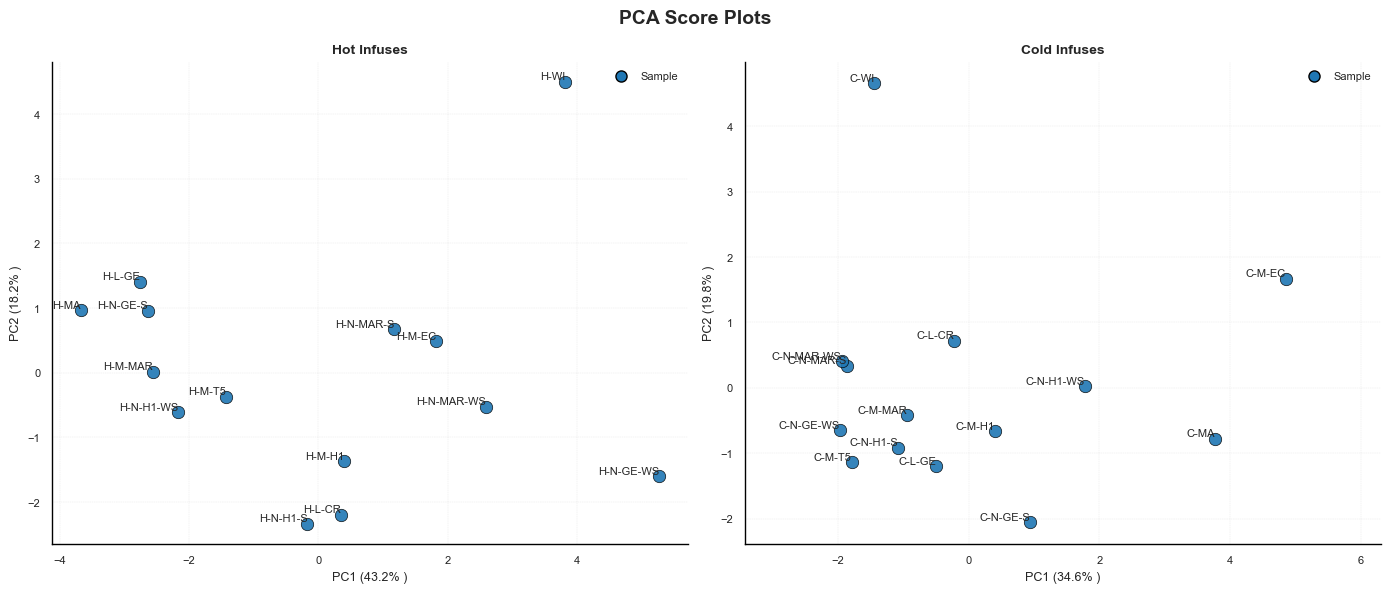

C:\Users\david\AppData\Local\Temp\ipykernel_12240\345685573.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')
C:\Users\david\AppData\Local\Temp\ipykernel_12240\345685573.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')


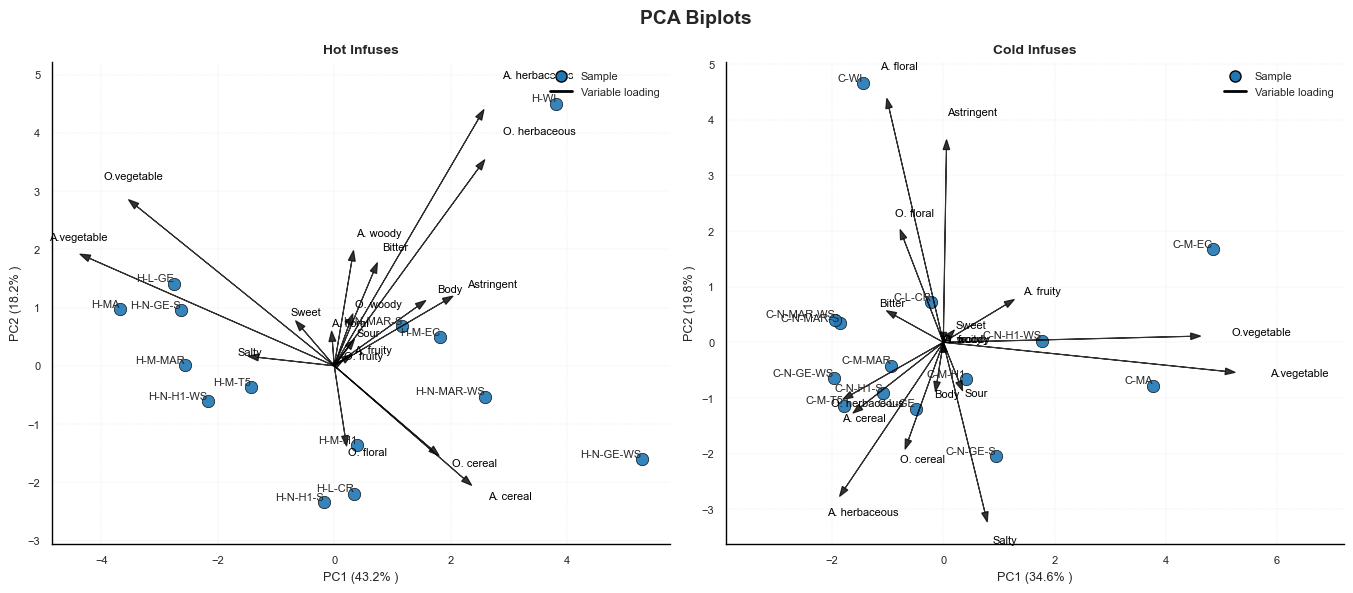

In [3]:
OUTPUT_DIR = Path("results/Sensory_analysis/PCA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from matplotlib.lines import Line2D

# === PCA SCORE PLOT FUNCTION ========================================
def plot_pca_score(df, title, ax):
    pca = PCA()
    pcs = pca.fit_transform(df.values)
    pc_df = pd.DataFrame(pcs[:, :2], index=df.index, columns=["PC1", "PC2"])

    # Styling for the specific axis
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    sns.scatterplot(
        data=pc_df,
        x="PC1",
        y="PC2",
        s=80,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
        ax=ax,
        legend=False,
        color="tab:blue"
    )
    for i, sample in enumerate(pc_df.index):
        ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')

    ev = pca.explained_variance_ratio_ * 100
    ax.set_title(title, fontsize=10, pad=6, weight='bold')
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% )", fontsize=9)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}% )", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.axis("equal")

    # Legend
    handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markeredgecolor='black', markersize=8, label='Sample')]
    ax.legend(handles=handles, labels=['Sample'], loc='best', fontsize=8, frameon=False)

# === PCA BIPLOT FUNCTION ================================================
def plot_pca_biplot(df, title, ax):
    pca = PCA()
    pcs = pca.fit_transform(df.values)
    pc_df = pd.DataFrame(pcs[:, :2], index=df.index, columns=["PC1", "PC2"])

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    sns.scatterplot(
        data=pc_df,
        x="PC1",
        y="PC2",
        s=80,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.9,
        ax=ax,
        legend=False,
        color="tab:blue"
    )
    for i, sample in enumerate(pc_df.index):
        ax.text(pc_df.PC1[i], pc_df.PC2[i], sample, fontsize=8, ha='right', va='bottom')

    # Biplot arrows 
    loadings = pca.components_.T
    feature_names = df.columns
    arrow_scale = 8 # arrow length scaling factor
    for i, var in enumerate(feature_names):
        ax.arrow(0, 0, loadings[i, 0]*arrow_scale, loadings[i, 1]*arrow_scale,
                 color='black', alpha=0.8, head_width=0.12, length_includes_head=True, label='_var_arrow')
        ax.text(loadings[i, 0]*arrow_scale*1.12, loadings[i, 1]*arrow_scale*1.12, var, color='black', fontsize=8)

    # Legend
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markeredgecolor='black', markersize=8, label='Sample'),
        Line2D([0], [0], color='black', lw=2, label='Variable loading')
    ]
    ax.legend(handles=handles, labels=['Sample', 'Variable loading'], loc='best', fontsize=8, frameon=False)

    ev = pca.explained_variance_ratio_ * 100
    ax.set_title(title, fontsize=10, pad=6, weight='bold')
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% )", fontsize=9)
    ax.set_ylabel(f"PC2 ({ev[1]:.1f}% )", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
    ax.axis("equal")

# === RUN PCA AND PLOT =====================================
sns.set_theme(style="white", context="paper")

# 1. Score Plots Combined
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
fig.suptitle("PCA Score Plots", fontsize=14, weight='bold')

plot_pca_score(hot_panel, "Hot Infuses", axes[0])
plot_pca_score(cold_panel, "Cold Infuses", axes[1])

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_scores.jpg", dpi=600)
plt.savefig(OUTPUT_DIR / "pca_scores.svg")
plt.show()

# 2. Biplots Combined
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
fig.suptitle("PCA Biplots", fontsize=14, weight='bold')

plot_pca_biplot(hot_panel, "Hot Infuses", axes[0])
plot_pca_biplot(cold_panel, "Cold Infuses", axes[1])

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_biplots.jpg", dpi=600)
plt.savefig(OUTPUT_DIR / "pca_biplots.svg")
plt.show()

## MCA


MCA analysis: Hot Infusions
Explained variance per component:
  Component 1: 15.95%
  Component 2: 13.92%
  Component 3: 12.35%
  Component 4: 11.33%
  Component 5: 9.90%
Total first 2 components: 29.87%
Figures saved to results\Sensory_analysis\MCA
Figures saved to results\Sensory_analysis\MCA


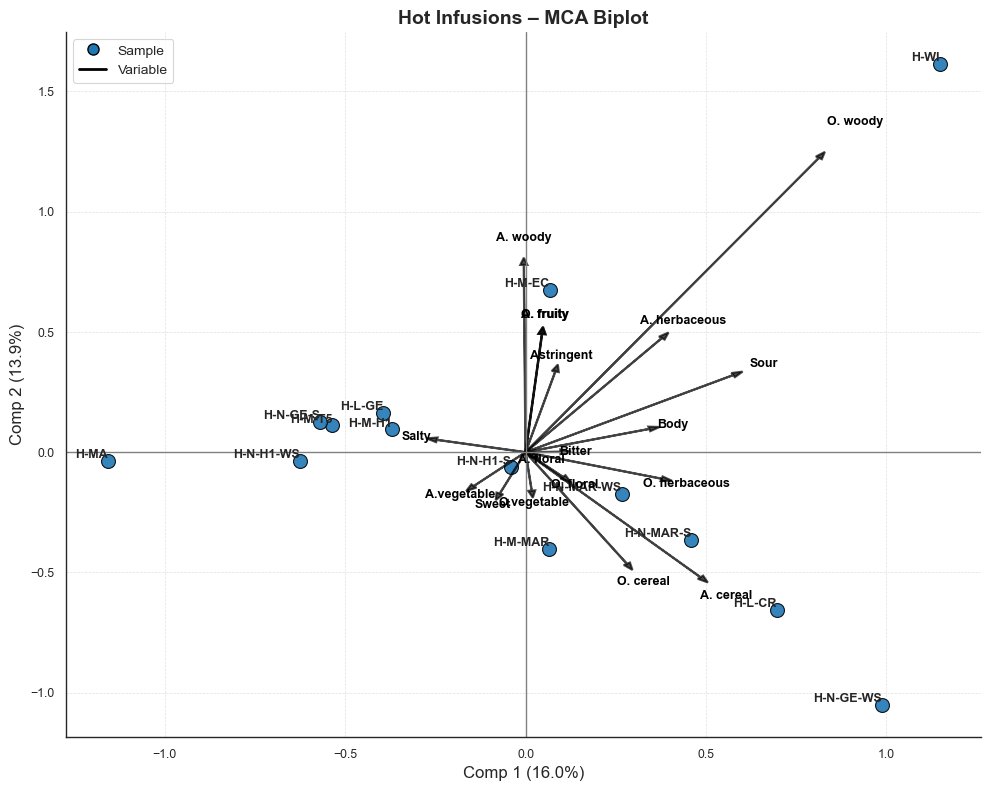


MCA analysis: Cold Infusions
Explained variance per component:
  Component 1: 14.80%
  Component 2: 13.59%
  Component 3: 12.17%
  Component 4: 10.61%
  Component 5: 8.33%
Total first 2 components: 28.38%
Figures saved to results\Sensory_analysis\MCA
Figures saved to results\Sensory_analysis\MCA


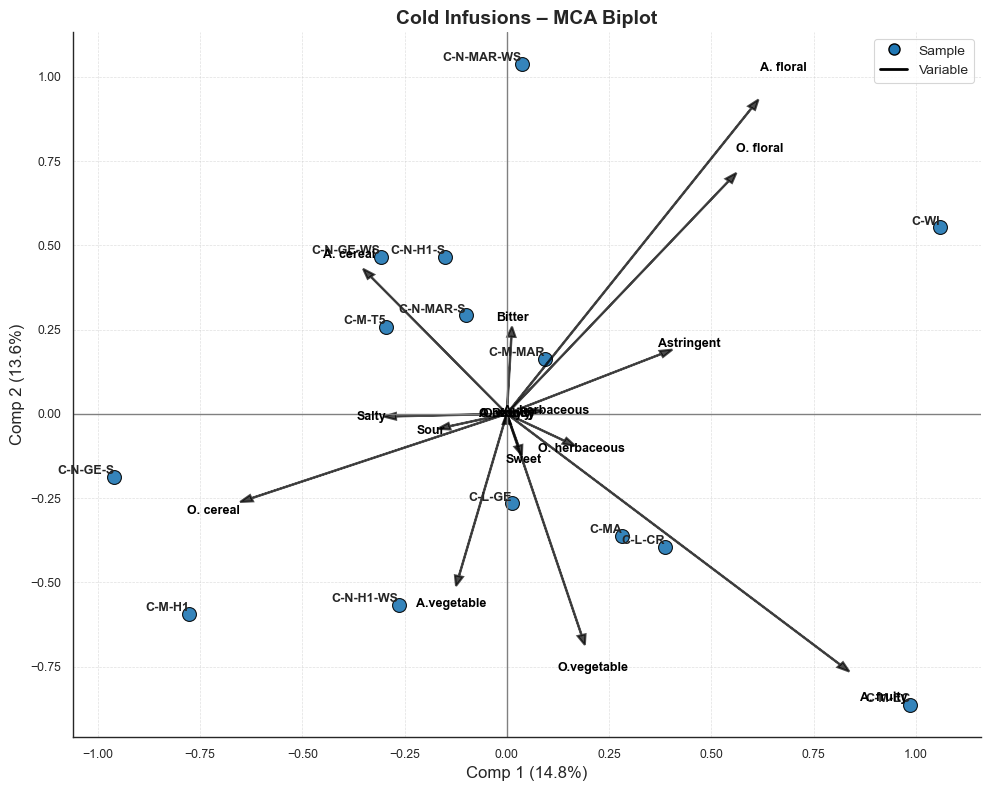

In [4]:
OUTPUT_DIR = Path("results\Sensory_analysis\MCA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# === Function to calculate variable contributions ===
def calculate_variable_contributions(mca_obj, df_dummies, n_components=2):
    # Get column coordinates (factor scores for columns)
    col_coords_arr = mca_obj.fs_c(N=n_components)
    col_coords = pd.DataFrame(col_coords_arr, index=df_dummies.columns)
    
    variable_contributions = {}
    
    # We iterate over the *original* variable prefixes (e.g., "Acidity")
    original_vars = set([c.rsplit('_', 1)[0] for c in df_dummies.columns])
    
    for var in original_vars:

        var_modalities = [col for col in col_coords.index if col.startswith(f"{var}_")]
        
        for comp in range(n_components):
            if comp not in variable_contributions:
                variable_contributions[comp] = {}
            
            # Calculate squared contribution of modalities
            contrib = sum([col_coords.loc[mod, comp]**2 for mod in var_modalities if mod in col_coords.index])
            variable_contributions[comp][var] = contrib
    
    return variable_contributions

# === Aggregate coordinates of variables ===
def get_variable_coordinates(mca_obj, df_dummies, original_columns, n_components=2):
    """
    Calculate the aggregate coordinates of variables as the mean of the coordinates 
    of their modalities (dummy columns).
    """
    # Extract column coordinates from mca object
    col_coords_arr = mca_obj.fs_c(N=n_components)
    col_coords = pd.DataFrame(col_coords_arr, index=df_dummies.columns)
    
    variable_coords = {}
    
    # Iterate through the original column names from the raw dataframe
    for var in original_columns:
        # Identify dummy columns that correspond to this variable
        # e.g. if var is "Aroma", look for "Aroma_High", "Aroma_Low"
        var_modalities = [col for col in col_coords.index if col.startswith(f"{var}_")]
        
        if var_modalities:
            # Calculate centroid (mean) of the modalities
            coords = col_coords.loc[var_modalities].mean(axis=0)
            variable_coords[var] = coords
            
    return pd.DataFrame(variable_coords).T

# === MCA ===
def run_mca(df, title, save_prefix):
    print(f"\n{'='*50}")
    print(f"MCA analysis: {title}")
    print(f"{'='*50}")
    
    # 1. PREPARE DATA: Convert to string and Create Indicator Matrix (One-Hot)
    df_cat = df.astype(str)
    
    # mca package requires a dummy matrix. 
    # We use prefix_sep='_' to ensure compatibility with helper functions
    df_dummies = pd.get_dummies(df_cat, prefix_sep='_')

    # 2. FIT MCA
    # benzecri=False gives standard Indicator Matrix analysis. Set True for Benzécri correction.
    mca_ben = mca.MCA(df_dummies, benzecri=False)

    # 3. EXTRACT VARIANCE
    # .expl_var returns variance fraction (0 to 1), so we multiply by 100
    explained_variance = mca_ben.expl_var(greenacre=False, N=5) * 100
    
    print("Explained variance per component:")
    for i, var in enumerate(explained_variance[:5]):
        print(f"  Component {i+1}: {var:.2f}%")
    print(f"Total first 2 components: {explained_variance[:2].sum():.2f}%")

    # 4. EXTRACT COORDINATES
    # Row coordinates (Factor scores for rows)
    # mca_ben.fs_r returns numpy array, map back to indices
    row_coords_arr = mca_ben.fs_r(N=5)
    row_coords = pd.DataFrame(row_coords_arr, index=df.index)

    # Variable Centroid Coordinates (Calculated via helper)
    var_coords = get_variable_coordinates(mca_ben, df_dummies, df_cat.columns, n_components=5)
    
    # 5. PLOT
    sns.set_theme(style="white", context="paper")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sample points
    sns.scatterplot(x=row_coords.iloc[:, 0], y=row_coords.iloc[:, 1],
                   s=100, edgecolor="black", linewidth=0.8, alpha=0.9,
                   ax=ax, color="tab:blue", label="Sample")
                   
    for i, sample in enumerate(df.index):
        ax.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], sample,
               fontsize=9, ha='right', va='bottom', weight='bold')

    # Variable arrows
    for var, (x, y) in var_coords.iloc[:, [0, 1]].iterrows():
        scaler = 1.0 
        
        ax.arrow(0, 0, x*scaler, y*scaler, color='black', alpha=0.7,
                 head_width=0.02, length_includes_head=True, linewidth=1.5)
        ax.text(x*scaler*1.1, y*scaler*1.1, var, color='black', fontsize=9,
                ha='center', va='center', weight='bold')
    
    ax.set_title(f"{title} – MCA Biplot", fontsize=14, weight='bold')
    ax.set_xlabel(f"Comp 1 ({explained_variance[0]:.1f}%)", fontsize=12)
    ax.set_ylabel(f"Comp 2 ({explained_variance[1]:.1f}%)", fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    
    handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',
               markeredgecolor='black', markersize=8, label='Sample'),
        Line2D([0], [0], color='black', lw=2, label='Variable')
    ]
    ax.legend(handles=handles, loc='best', fontsize=10, frameon=True)
    
    sns.despine()
    plt.tight_layout()
    
    # Ensure output directory exists before saving
    plt.savefig(OUTPUT_DIR /f"{save_prefix}_panel_mca_biplot.jpg", dpi=600, bbox_inches='tight')
    plt.savefig(OUTPUT_DIR /f"{save_prefix}_panel_mca_biplot.svg", bbox_inches='tight')
    print(f"Figures saved to {OUTPUT_DIR}")
    plt.show()
    
    return mca_ben, df_dummies

# === Execute ===
mca_hot, df_hot_dummies = run_mca(hot_panel, "Hot Infusions", "hot")
mca_cold, df_cold_dummies = run_mca(cold_panel, "Cold Infusions", "cold")

## Spider chart

Chart saved to: results\Sensory_analysis\Radar_charts\H-N-GE-WS_vs_C-N-GE-WS.png


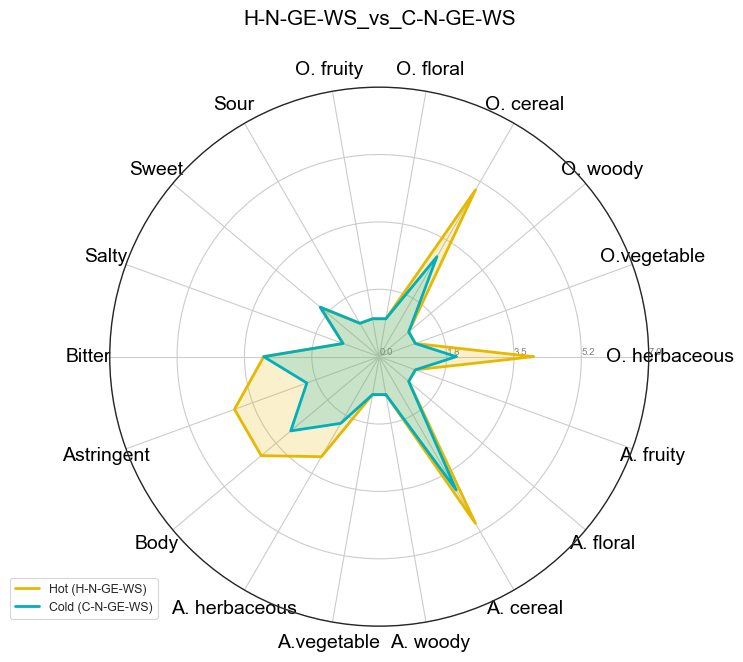

Chart saved to: results\Sensory_analysis\Radar_charts\H-M-EC_vs_C-M-EC.png


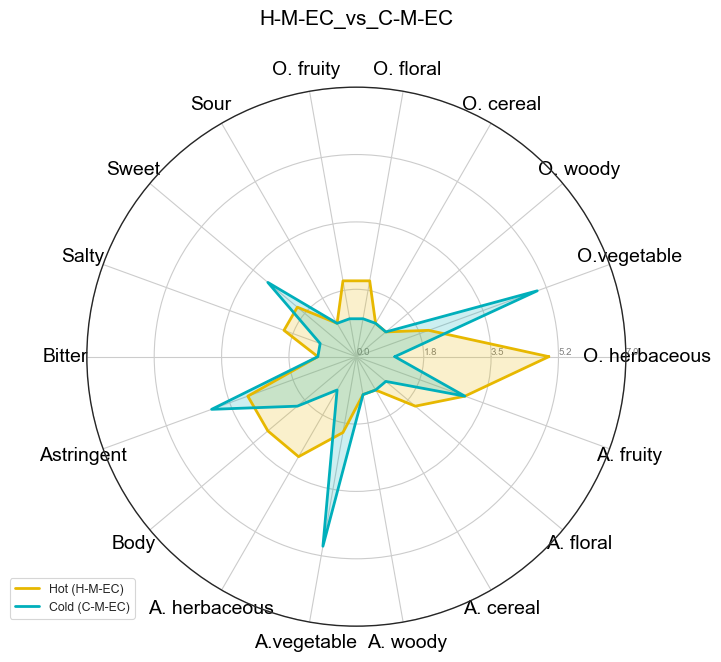

Chart saved to: results\Sensory_analysis\Radar_charts\H-MA_vs_C-MA.png


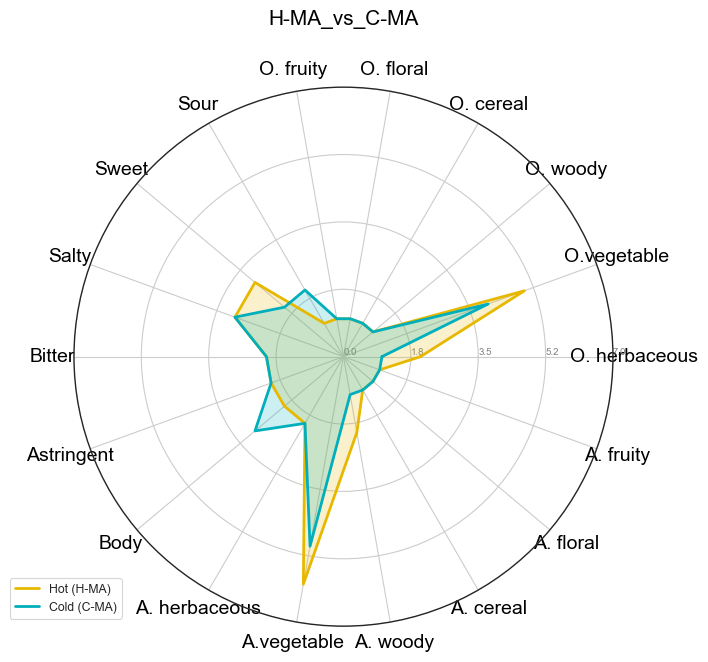

Chart saved to: results\Sensory_analysis\Radar_charts\H-M-T5_vs_C-M-T5.png


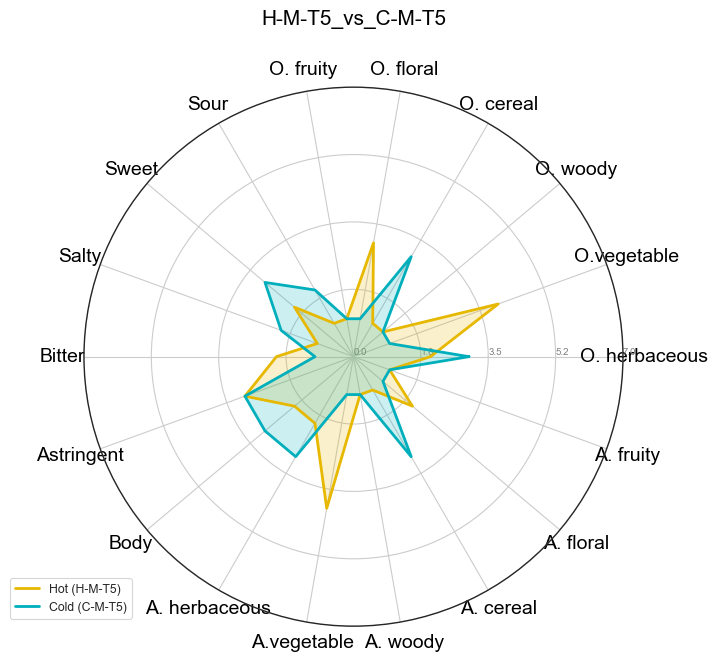

Chart saved to: results\Sensory_analysis\Radar_charts\H-WI_vs_C-WI.png


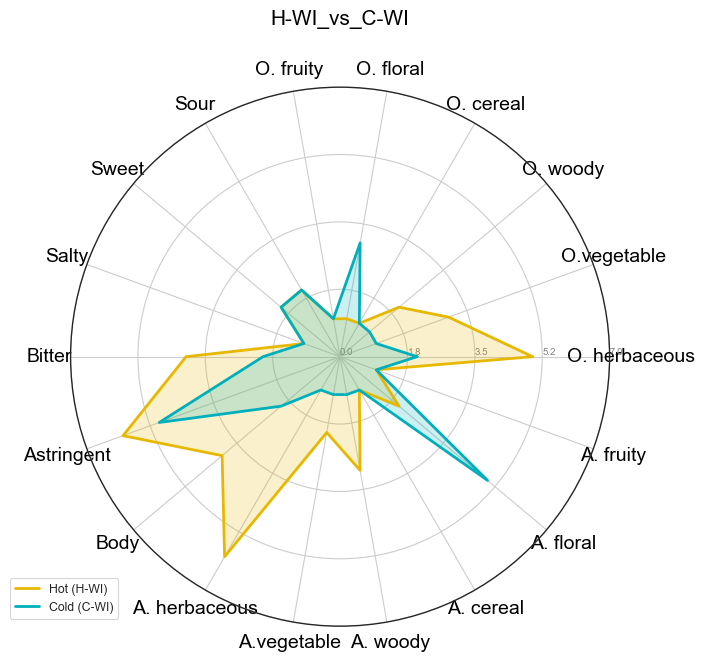

In [11]:
# Setup Output Directory
OUTPUT_DIR = Path("results\Sensory_analysis\Radar_charts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 2. RADAR CHART FUNCTION (UPDATED) ---
def create_spider_chart(data, samples, title, file_name, min_val=0, max_val=7, custom_colors=None):
    """
    Generates a spider chart comparing specific rows from a dataframe.
    """
    # Define attributes (categories)
    categories = list(data.columns)
    N = len(categories)

    # Determine angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the loop

    # Initialize plot
    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)

    # Draw one axe per variable + labels
    plt.xticks(angles[:-1], categories, color='black', size=14)

    # Draw y-labels (scales)
    ax.set_rlabel_position(0)
    plt.yticks(np.linspace(min_val, max_val, 5), 
               [str(round(x,1)) for x in np.linspace(min_val, max_val, 5)], 
               color="grey", size=7)
    plt.ylim(min_val, max_val)

    # Color palette
    if custom_colors:
        colors = custom_colors
    else:
        colors = sns.color_palette("husl", len(samples))

    # Plot each sample
    for idx, sample_name in enumerate(samples):
        if sample_name in data.index:
            values = data.loc[sample_name].values.flatten().tolist()
            values += values[:1] # Close the loop

            ax.plot(angles, values, linewidth=2, linestyle='solid', label=sample_name, color=colors[idx])
            ax.fill(angles, values, color=colors[idx], alpha=0.2)
        else:
            print(f"Warning: Sample '{sample_name}' not found in data.")

    # Legend and Title
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(title, size=15, color='black', y=1.1)

    # Save
    save_path = OUTPUT_DIR / f"{file_name}.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    svg_path = OUTPUT_DIR / f"{file_name}.svg"
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    print(f"Chart saved to: {save_path}")
    
    # Show plot (optional, comment out if running in batch)
    plt.show()
    plt.close()

# --- 3. HELPER: CROSS-DATASET COMPARISON (UPDATED) ---
def compare_hot_vs_cold(hot_id, cold_id, plot_title_suffix=""):
    """
    Extracts one row from Hot panel and one row from Cold panel,
    combines them, and plots the comparison 
    """
    if hot_id not in hot_panel.index:
        print(f"Error: ID '{hot_id}' not found in HOT dataset.")
        return
    if cold_id not in cold_panel.index:
        print(f"Error: ID '{cold_id}' not found in COLD dataset.")
        return

    # 2. Create Comparison Dataframe
    # Index 0 = Hot, Index 1 = Cold
    comparison_df = pd.DataFrame({
        f"Hot ({hot_id})": hot_panel.loc[hot_id],
        f"Cold ({cold_id})": cold_panel.loc[cold_id]
    }).T 

    # 3. Define Filename and Title
    safe_title = f"{hot_id}_vs_{cold_id}"

    # Index 0 (Hot) gets #E7B800
    # Index 1 (Cold) gets #00AFBB
    my_colors = ['#E7B800', '#00AFBB']

    create_spider_chart(
        data=comparison_df,
        samples=comparison_df.index.tolist(),
        title=safe_title,
        file_name=safe_title,
        min_val=0,
        max_val=7,
        custom_colors=my_colors  # Passing the colors here
    )

# Run comparisons
pairs_to_compare = [ 
    ('H-N-GE-WS', 'C-N-GE-WS'),
    ('H-M-EC', 'C-M-EC'),
    ('H-MA', 'C-MA'),
    ('H-M-T5', 'C-M-T5'),
    ('H-WI', 'C-WI'),
] # Sample ID pairs

for h_id, c_id in pairs_to_compare:
    compare_hot_vs_cold(h_id, c_id, plot_title_suffix=f"Comparison: {h_id}/{c_id}")